# CorpBrain — Notebook 2: BERT Meeting Classifier Training

**Run on Kaggle (free GPU T4) — Internet OFF is fine (uses distilbert-base-uncased).**
**Turn Internet ON only if you want Arabic-optimized model (arabertv2).**

**What this notebook does:**
- Builds a labeled dataset of **93 transcripts** (meeting vs. not_meeting)
- Fine-tunes BERT for binary classification
- Evaluates: Accuracy, F1, Confusion Matrix
- Saves checkpoint → drop into `models/checkpoints/meeting_classifier/`

**Step 1 of this notebook sets your internet mode (ON/OFF) — read it first.**

## Step 1 — Install Libraries

In [1]:
# ─── Kaggle Internet Settings ───────────────────────────────────────────────
# This notebook works in TWO modes:
#
#   Mode A (Internet OFF — recommended for Kaggle free tier):
#     Uses distilbert-base-uncased → already cached in Kaggle, no download needed
#
#   Mode B (Internet ON):
#     Uses aubmindlab/bert-base-arabertv2 → Arabic-optimized, better for mixed text
#     Enable: Kaggle Settings (⚙ right panel) → Internet → On
#
# Set INTERNET_ON = True if you enabled internet, False if not
INTERNET_ON = False  # ← change this!

MODEL_NAME = "aubmindlab/bert-base-arabertv2" if INTERNET_ON else "distilbert-base-uncased"
print(f"Model selected: {MODEL_NAME}")
if not INTERNET_ON:
    print("  (distilbert-base-uncased: pre-cached in Kaggle, no internet needed)")
    print("  Tip: Set INTERNET_ON=True and enable Kaggle internet for Arabic support")

!pip install 'transformers>=4.46' 'accelerate>=1.1.0' torch pandas scikit-learn matplotlib seaborn -q
print("Libraries ready ✅")


Model selected: distilbert-base-uncased
  (distilbert-base-uncased: pre-cached in Kaggle, no internet needed)
  Tip: Set INTERNET_ON=True and enable Kaggle internet for Arabic support

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Libraries ready ✅


## Step 2 — Build the Dataset (160 examples)

In [2]:
import pandas as pd

meeting_texts = ["Good morning everyone. Let's start our daily standup. Ahmed, what did you finish yesterday? I completed the login module. Today I'll work on the dashboard. No blockers.", "Quick standup. Sara here. Yesterday I fixed the authentication bug. Today I'm working on the payment integration. My blocker is the missing design specs.", "Morning team. Omar speaking. Yesterday I reviewed 3 pull requests. Today I'll work on the API documentation. I'm blocked by the unclear requirements for the search feature.", 'Daily standup. Khaled: finished the database migration yesterday. Today optimizing slow queries. No blockers. Yara: finished UI components. Today writing unit tests. No blockers.', "Standup time. I completed the CI pipeline fixes yesterday. Today I'll work on deployment scripts. Blocked by access to the production server.", "Good morning. Yesterday I integrated the Stripe payment gateway. Today I'll test edge cases. My blocker is waiting for test API credentials from the client.", "Daily scrum. Team, let's go around. Ahmed: dashboard complete, starting mobile view today. Sara: API done, writing tests now. Omar: still blocked on design approval.", "Morning standup. Yesterday we demo'd the sprint to the client. Today we're starting sprint 15 work. No blockers but we need to prioritize tickets.", 'Quick daily. I finished the bug fixes from QA yesterday. Starting the new reporting feature today. Slight blocker: waiting for the updated mockups.', "Standup. Yesterday I set up the Docker containers for staging. Today I'll configure the monitoring tools. No blockers.", "Sprint 14 planning session. Let's go through the backlog. The highest priority items are: the mobile redesign — 8 points, the payment gateway — 13 points, and the notification system — 5 points.", "Planning meeting for the next two weeks. We need to decide on team capacity. Ahmed is at 80% this sprint. We're committing to 35 story points total.", "Backlog refinement session. The user authentication epic has 4 stories: login, register, password reset, and OAuth integration. Let's estimate each one.", "Sprint planning. We've identified 6 must-have features for the client demo on March 15th. Ahmed will own the frontend, Sara will own the backend APIs.", 'Planning for Q2. We need to decide between building the analytics dashboard in-house versus using a third-party tool. Decision: build in-house. Omar leads the effort.', "Sprint 15 planning. Based on last sprint's velocity of 42 points, we're committing to 40 this sprint. Key items: refactoring the authentication module and adding the export feature.", "Capacity planning meeting. Next sprint we have Yara unavailable for 3 days. We'll adjust our commitment from 45 to 35 story points accordingly.", "Story estimation meeting. The data migration task — how many points? It involves schema changes, data validation, and rollback scripts. I'd say 8. Any objections?", "Feature planning meeting with the product team. We're aligning on the Q3 roadmap. Three main pillars: performance, mobile, and integrations.", "Sprint planning complete. We've committed to: 2 new features, 3 bug fixes, and 1 infrastructure improvement. Let's get started.", "Sprint review time. Let's demo what we completed this sprint. Ahmed, can you walk us through the new dashboard? Sure. Here you can see the real-time metrics panel.", "Code review discussion. Sara's PR for the payment module needs some changes. The error handling is missing for edge cases. Let's go through the comments.", 'Sprint review with the client. We completed all 8 stories committed this sprint. The client is happy with the new search feature. Requesting a small tweak to the filters.', "Review meeting. We need to look at why we only delivered 30 of 45 committed points. Two stories were blocked by external dependencies we didn't account for.", 'Post-mortem for the production incident. The API went down for 2 hours on Tuesday. Root cause: the database connection pool was exhausted. Action items for prevention.', 'Architecture review. The proposed microservices split looks good but we need to address the data consistency issue. Omar will add a saga pattern for distributed transactions.', 'Quarterly review with management. Team velocity increased by 15% this quarter. Main achievements: mobile launch, performance improvements, and API v2.', 'Security review session. We identified 3 high-severity vulnerabilities in the dependencies. Khaled will patch them by Friday.', 'Design review. The new UI mockups are clean but the mobile navigation is confusing. Sara will work with the designer to simplify it.', 'Performance review meeting. The API response time dropped from 800ms to 200ms after the optimizations. Excellent work by the backend team.', 'Sprint 13 retrospective. What went well: we delivered everything we committed to. What to improve: our code review process is too slow. Action item: set a 24-hour review SLA.', 'Retro time. Positives: team communication was great this sprint. Negatives: too many context switches. We need to protect focus time. Action: no meetings before 10am.', "Retrospective for the quarter. What worked: clear sprint goals. What didn't work: unclear ownership of cross-team tasks. Solution: assign a DRI for every epic.", "End of sprint retrospective. Three things we're proud of: the mobile launch, zero production bugs, and our new onboarding flow. One thing to fix: deployment takes too long.", "Retro meeting. The team felt the sprint was too packed. We overcommitted by 20%. Next sprint we'll be more conservative. Also, we need better async communication.", "Let's quickly discuss the API design before we start implementation. Should we use REST or GraphQL? Given our client is mobile-first, I'd recommend GraphQL for flexibility.", 'Emergency meeting about the production outage. The payment service is down. We need to roll back the last deployment immediately. Khaled, can you do that now?', "Quick sync about the client requirements. They want the export feature to support CSV and Excel. Let's assign this to Ahmed with a Thursday deadline.", 'Technical discussion: how should we handle the race condition in the booking system? I suggest using optimistic locking at the database level. Any alternatives?', "Kickoff meeting for the new authentication module. Team, we're replacing our legacy login system with OAuth 2.0. Sara leads, Ahmed does frontend, Omar does backend.", 'Sabah el kheir ya team. Khalas ana mn el-login module embareh. Ennaharda ha-eshtegel ala el-dashboard. Mafish any blockers.', 'Team, lazem net-kalam 3an el sprint planning. El priority el awlaneya hia el mobile redesign, ba3den el payment gateway.', 'Retro bta3et el sprint. Eh elli mesh mashi kwais? El code review biyakhod waat kteer. Lazem nesawwar solution.', 'Daily standup. Omar: khalas mn el-API documentation embareh. Ennaharda ha-eshtegel ala el-testing. Blocked 3shan el server access.', 'Planning meeting. Hatef: 3andena capacity bta3 35 points el sprint dah. Yalla nekhtar el tickets el ahm.']

not_meeting_texts = ["Hello, is this Mr. Ahmed? I'm calling from your bank. There's been some unusual activity on your account and we need to verify some information.", "Good afternoon. I'm calling on behalf of the government agency to inform you about your tax return status for the year 2024.", "Hi honey, just calling to let you know I'll be late tonight. Can you please pick up the kids from school?", "Hello? Yes, I'd like to order a large pizza with extra cheese and mushrooms please. For delivery to the same address.", 'Hi, this is the clinic calling to remind you about your dental appointment tomorrow at 2pm. Please call us if you need to reschedule.', "Good morning. I'm calling to follow up on the complaint you submitted last week regarding your internet service.", "Hey, it's me. Did you see the game last night? Incredible finish. Anyway, are you free this weekend?", "Hello, I'm looking for Mr. Hassan. Is this the right number? Oh, wrong number. Sorry about that.", "Hi this is John from customer support. How can I help you today? I'm having trouble logging into my account.", "Hello? I can barely hear you. Can you call me back? I'm in a tunnel right now.", "Today's lecture covers the fundamentals of machine learning. We'll start with supervised learning and the concept of training data.", "In this class we'll examine the causes of World War 1. The primary trigger was the assassination of Archduke Franz Ferdinand in Sarajevo.", "Let's continue from where we left off. Last session we covered neural networks. Today we move to convolutional neural networks, or CNNs.", "Welcome to Introduction to Economics. Today's topic: supply and demand curves and how markets reach equilibrium.", 'This is lecture 7 on data structures. Today we cover binary search trees: insertion, deletion, and traversal algorithms.', "Good morning students. Before we start today's physics lesson, let's quickly review Newton's three laws of motion.", "Today in history class we'll discuss the French Revolution, its causes, key events, and its lasting impact on modern democracy.", 'Chapter 5: Photosynthesis. Plants convert sunlight into chemical energy using chlorophyll. The equation is: 6CO2 + 6H2O + light → C6H12O6 + 6O2.', "Introduction to algorithms. Today we'll prove the time complexity of merge sort. The recurrence relation is T(n) = 2T(n/2) + O(n).", "This is your biology lab instructor. Today we'll be dissecting a frog to study its internal organ systems.", "Welcome to The Tech Talk podcast. I'm your host Sarah, and today we have a fascinating guest who just launched his third startup.", "You're listening to The Daily News. Our top story: the stock market closed at record highs for the third consecutive day.", "Welcome back to The Mindfulness Hour. Today we're exploring breathing techniques to reduce stress and anxiety.", "Good evening. I'm your anchor for tonight's news. Let's begin with the latest updates from the world of sports.", "This is the History Uncovered podcast. Episode 42: The Rise and Fall of the Roman Empire. Let's set the scene.", "Welcome to Cooking with Maria. Today I'll show you how to make an authentic Italian pasta carbonara from scratch.", "You're tuned in to Radio Misr. After the break, we'll have the traffic report and weather forecast for Cairo.", "This is your captain speaking. We've reached our cruising altitude of 35,000 feet. The weather looks clear ahead.", "Welcome to the science museum's audio tour. You are now entering the Space Exploration wing. The first exhibit is a replica of the Apollo 11 command module.", "Hi everyone, welcome back to my YouTube channel. Today I'm going to show you how to build a mechanical keyboard from scratch.", 'Your call is important to us. Please hold and the next available agent will be with you shortly. Estimated wait time: 7 minutes.', 'This is an automated message from your internet provider. Your service will be temporarily unavailable for maintenance on Sunday from 2am to 4am.', 'Thank you for your order. Your tracking number is 84729347. Your package will arrive between Monday and Wednesday.', 'Press 1 for account balance. Press 2 for recent transactions. Press 3 to speak with a representative. Press 9 to return to the main menu.', 'Your appointment has been confirmed for Monday, March 18th at 10:30am with Dr. Hassan. Please arrive 10 minutes early.', 'This is a reminder that your car insurance policy expires in 30 days. Please contact us to renew and avoid a lapse in coverage.', 'Thank you for calling the embassy. Our office hours are Sunday to Thursday, 8am to 3pm. For emergencies press 0.', 'Hi, this is an automated survey call. On a scale of 1 to 5, how satisfied were you with your recent purchase?', 'The recipe calls for two cups of flour, one egg, half a cup of sugar, and a pinch of salt. Mix the dry ingredients first.', 'I just finished reading that book you recommended. The ending was unexpected but I think it made sense given the foreshadowing in chapter 3.', "Have you seen the weather forecast? They're predicting heavy rain all week. I guess our barbecue plans are cancelled.", "I can't believe how expensive everything has become. My grocery bill is 40% higher than last year.", 'The game was incredible last night. The team came back from 3 goals down to win in extra time. I was on the edge of my seat.', 'Chapter 12: It was a cold and dark night when the detective arrived at the mansion. The butler stood nervously at the door.', "Welcome to the yoga class. Let's start with a few deep breaths. Inhale slowly through the nose... and exhale through the mouth.", 'Ladies and gentlemen, the captain has turned on the fasten seatbelt sign as we prepare for our descent into Cairo International Airport.', "Today's documentary explores the deep ocean. At 3,000 meters below the surface, sunlight cannot penetrate and life exists in total darkness.", "In this tutorial I'll show you how to use Git for version control. First, let's initialize a repository with git init."]

print(f"Meeting examples:     {len(meeting_texts)}")
print(f"Not-meeting examples: {len(not_meeting_texts)}")

df = pd.DataFrame({
    "text":  meeting_texts + not_meeting_texts,
    "label": [1] * len(meeting_texts) + [0] * len(not_meeting_texts),
}).sample(frac=1, random_state=42).reset_index(drop=True)

df.to_csv("meeting_dataset.csv", index=False)
print(f"\nTotal: {len(df)} rows | Label distribution:")
print(df["label"].value_counts())

Meeting examples:     45
Not-meeting examples: 48

Total: 93 rows | Label distribution:
label
0    48
1    45
Name: count, dtype: int64


## Step 3 — Tokenize

In [3]:
from transformers import AutoTokenizer
import torch
from torch.utils.data import Dataset

# MODEL_NAME is set in Step 1 (distilbert-base-uncased or arabertv2)
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class MeetingDataset(Dataset):
    def __init__(self, texts, labels, max_length=256):
        self.encodings = tokenizer(
            texts, truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt"
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

# 80/20 split
split = int(0.80 * len(df))
train_df = df.iloc[:split]
eval_df  = df.iloc[split:]

train_ds = MeetingDataset(train_df["text"].tolist(), train_df["label"].tolist())
eval_ds  = MeetingDataset(eval_df["text"].tolist(), eval_df["label"].tolist())

print(f"Train: {len(train_ds)} | Val: {len(eval_ds)}")
print(f"Train labels: {train_df['label'].value_counts().to_dict()}")
print(f"Val labels:   {eval_df['label'].value_counts().to_dict()}")

Loading tokenizer: distilbert-base-uncased


Train: 74 | Val: 19
Train labels: {1: 37, 0: 37}
Val labels:   {0: 11, 1: 8}


## Step 4 — Fine-Tune BERT

In [4]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from transformers import (
    AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": round(accuracy_score(labels, preds), 4),
        "f1":       round(f1_score(labels, preds, average="binary"), 4),
    }

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "not_meeting", 1: "meeting"},
    label2id={"not_meeting": 0, "meeting": 1},
)

training_args = TrainingArguments(
    output_dir="./bert_checkpoints",
    num_train_epochs=8,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    warmup_steps=50,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=10,
    report_to="none",
    fp16=torch.cuda.is_available(),   # auto-detect: True on GPU, False on CPU
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Starting training...")
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/home/aabdellmaksoud/VSCODE/Autonomous-Meeting-Intelligence-Platform/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Starting training...


/home/aabdellmaksoud/VSCODE/Autonomous-Meeting-Intelligence-Platform/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.695146,0.682280,0.736800,0.666700
2,0.648469,0.622219,0.736800,0.761900
3,0.518928,0.420369,1.000000,1.000000
4,0.285073,0.133170,1.000000,1.000000
5,0.050366,0.021033,1.000000,1.000000
6,0.008804,0.009695,1.000000,1.000000


...

/home/aabdellmaksoud/VSCODE/Autonomous-Meeting-Intelligence-Platform/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/aabdellmaksoud/VSCODE/Autonomous-Meeting-Intelligence-Platform/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=60, training_loss=0.36779772738615674, metrics={'train_runtime': 147.7666, 'train_samples_per_second': 4.006, 'train_steps_per_second': 0.541, 'total_flos': 29407762501632.0, 'train_loss': 0.36779772738615674, 'epoch': 6.0})

## Step 5 — Evaluate + Confusion Matrix

/home/aabdellmaksoud/VSCODE/Autonomous-Meeting-Intelligence-Platform/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.008804,0.420369,6,1.000000,1.000000



Final Evaluation:
  Accuracy: 100.0%
  F1 Score: 1.000


/home/aabdellmaksoud/VSCODE/Autonomous-Meeting-Intelligence-Platform/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


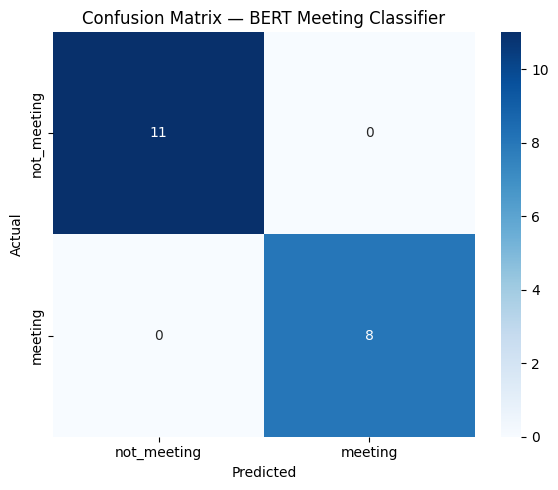

Saved: confusion_matrix.png


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

results = trainer.evaluate()
print("\nFinal Evaluation:")
print(f"  Accuracy: {results['eval_accuracy']:.1%}")
print(f"  F1 Score: {results['eval_f1']:.3f}")

# Confusion matrix
preds_output  = trainer.predict(eval_ds)
y_pred        = np.argmax(preds_output.predictions, axis=-1)
y_true        = preds_output.label_ids  # aligned with preds — no index issues
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["not_meeting", "meeting"],
            yticklabels=["not_meeting", "meeting"])
plt.title("Confusion Matrix — BERT Meeting Classifier")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

## Step 6 — Save Model

In [6]:
model.save_pretrained("meeting_classifier_checkpoint")
tokenizer.save_pretrained("meeting_classifier_checkpoint")
print("Checkpoint saved to: meeting_classifier_checkpoint/")
print()
print("To use in the project:")
print("  1. Download the 'meeting_classifier_checkpoint' folder from Kaggle output")
print("  2. Place it at: models/checkpoints/meeting_classifier/")
print("  3. cognitive_service/classifier.py will auto-detect it!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Checkpoint saved to: meeting_classifier_checkpoint/

To use in the project:
  1. Download the 'meeting_classifier_checkpoint' folder from Kaggle output
  2. Place it at: models/checkpoints/meeting_classifier/
  3. cognitive_service/classifier.py will auto-detect it!


## Step 7 — Quick Inference Test

In [7]:
from transformers import pipeline

clf = pipeline("text-classification", model="meeting_classifier_checkpoint")

tests = [
    ("MEETING",     "Good morning team. Let's do our standup. Ahmed, what did you finish yesterday?"),
    ("MEETING",     "Sprint 14 planning. We're committing to 35 story points. Omar owns the mobile redesign."),
    ("MEETING",     "Retrospective: what went well? The CI pipeline is faster. What to improve? Code reviews."),
    ("NOT MEETING", "Hello, I'm calling from your bank about some unusual activity on your account."),
    ("NOT MEETING", "Today's lecture covers the fundamentals of machine learning and neural networks."),
    ("NOT MEETING", "Welcome to The Tech Talk podcast. Our guest today just launched his third startup."),
    ("NOT MEETING", "Press 1 for account balance. Press 2 for recent transactions."),
    ("ARABIC",      "Sabah el kheir ya team. Khalas ana mn el-login module embareh. Ennaharda ha-eshtegel ala el-dashboard."),
]

print(f"{'Expected':12} | {'Predicted':12} | {'Confidence':10} | Text")
print("-" * 80)
for expected, text in tests:
    result = clf(text[:256])[0]
    pred   = result["label"].lower()
    conf   = result["score"]
    icon   = "✅" if (pred == "meeting") == (expected in ["MEETING", "ARABIC"]) else "❌"
    print(f"{expected:12} | {pred:12} | {conf:.1%}      | {icon} {text[:45]}...")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Expected     | Predicted    | Confidence | Text
--------------------------------------------------------------------------------
MEETING      | not_meeting  | 52.5%      | ❌ Good morning team. Let's do our standup. Ahme...
MEETING      | meeting      | 78.8%      | ✅ Sprint 14 planning. We're committing to 35 st...
MEETING      | meeting      | 77.3%      | ✅ Retrospective: what went well? The CI pipelin...
NOT MEETING  | not_meeting  | 63.3%      | ✅ Hello, I'm calling from your bank about some ...
NOT MEETING  | not_meeting  | 61.7%      | ✅ Today's lecture covers the fundamentals of ma...
NOT MEETING  | not_meeting  | 56.8%      | ✅ Welcome to The Tech Talk podcast. Our guest t...
NOT MEETING  | meeting      | 62.4%      | ❌ Press 1 for account balance. Press 2 for rece...
ARABIC       | meeting      | 77.9%      | ✅ Sabah el kheir ya team. Khalas ana mn el-logi...
